In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Initialize empty 128x128 arrays for ON and OFF events
on_events  = np.zeros((128, 128), dtype=int)
off_events = np.zeros((128, 128), dtype=int)

In [ ]:
def parse_sim_output(filepath, row_offset=0):
    """
    Parses the 136-bit hex strings from the SystemVerilog simulation.
    Format: {Control[135:128], LeftData[127:64], RightData[63:0]}
    """
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return

    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        # Convert the 34-character hex string to a massive Python integer
        word = int(line, 16)
        
        # Slice the bits using bitwise masking and shifting
        data_right = word & ((1 << 64) - 1)                  # Bits [63:0]
        data_left  = (word >> 64) & ((1 << 64) - 1)          # Bits [127:64]
        ctrl_byte  = (word >> 128) & 0xFF                    # Bits [135:128]
        
        # Extract metadata from the Control Byte
        event_mode = (ctrl_byte >> 6) & 0b11                 # Top 2 bits of ctrl
        row_addr   = ctrl_byte & 0b111111                    # Bottom 6 bits of ctrl
        
        if 0 <= row_addr < 64:
            global_y = row_addr + row_offset
        if event_mode == 2:
            on_events[global_y] = row_array
        elif event_mode == 1:
            off_events[global_y] = row_array
        
        # Calculate global absolute Y coordinate (0 to 127)
        global_y = row_addr + row_offset
        
        # Concatenate left and right halves back into a 128-bit row
        full_row_data = (data_left << 64) | data_right
        
        # Convert the 128-bit int into a boolean numpy array of length 128
        # format(..., '0128b') pads the binary string with leading zeros up to 128 chars
        bin_str = format(full_row_data, '0128b')
        row_array = np.array([int(pixel) for pixel in bin_str])
        
        # Route the data to the correct image plane based on the event mode flag
        if event_mode == 2:   # 2'b10
            on_events[global_y] = row_array
        elif event_mode == 1: # 2'b01
            off_events[global_y] = row_array

    print(f"Successfully parsed {len(lines)} rows from {filepath}")

In [28]:
# 1. Parse the Top Tier (Rows 0-63)
# Make sure to update the path to wherever your sim_output files were generated
parse_sim_output('sim_output_top.txt', row_offset=0)

# 2. Parse the Bottom Tier (Rows 64-127)
parse_sim_output('sim_output_bot.txt', row_offset=64)

# Note on Endianness: 
# If your reconstructed image looks perfectly mirrored left-to-right, 
# uncomment the two lines below. It just means the Verilog bus mapping [127:0] 
# corresponds to physical columns [0:127] instead of [127:0].
# on_events = np.fliplr(on_events)
# off_events = np.fliplr(off_events)

Successfully parsed 128 rows from sim_output_top.txt
Successfully parsed 128 rows from sim_output_bot.txt


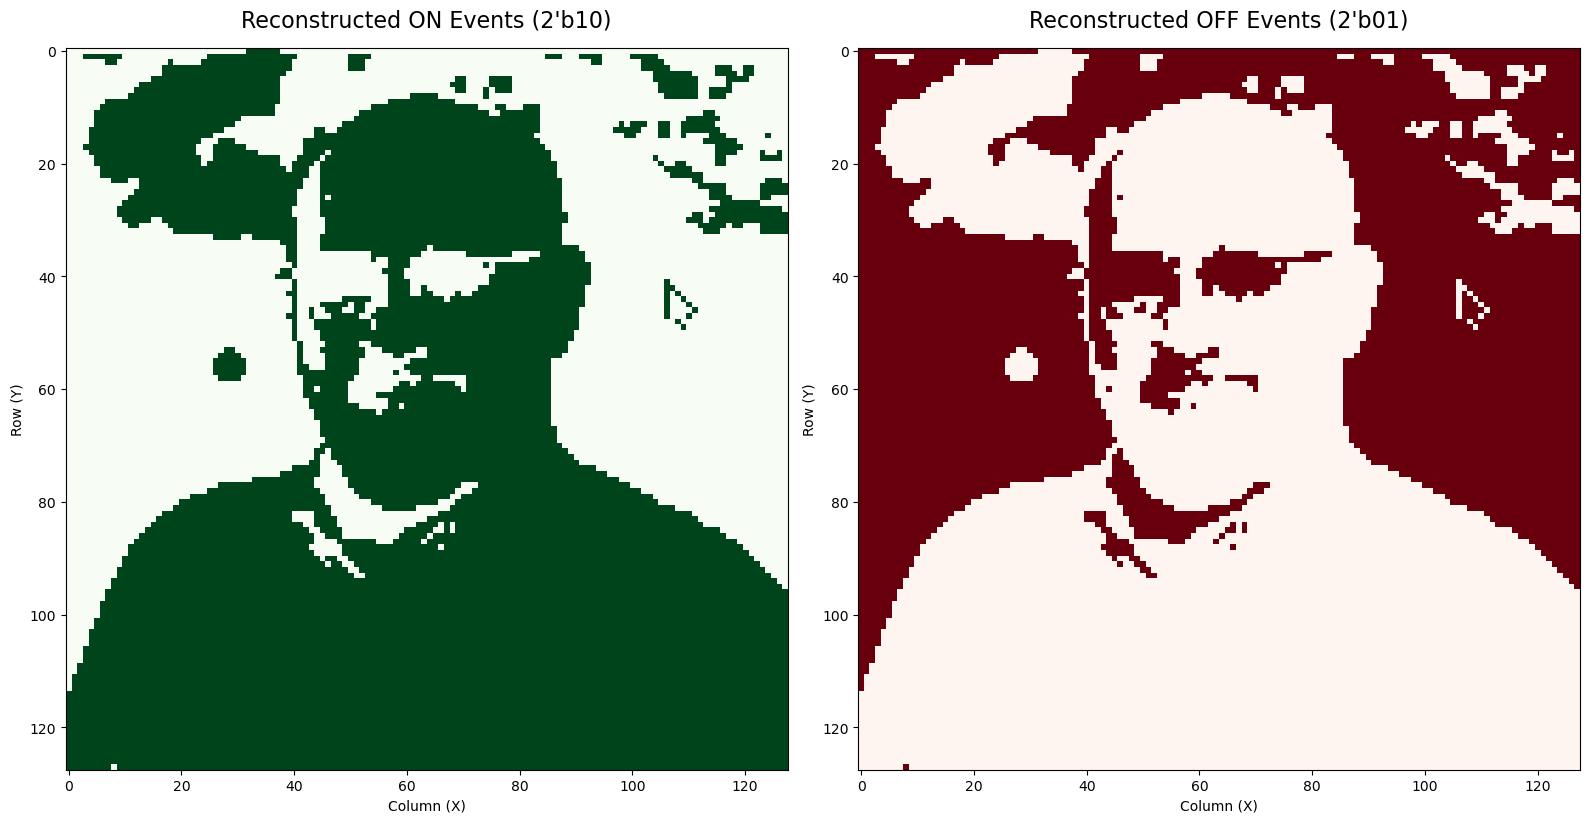

In [29]:
# 3. Visualize the Results
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot ON Events (Green/Hot)
cax1 = axes[0].imshow(on_events, cmap='Greens', interpolation='nearest')
axes[0].set_title('Reconstructed ON Events (2\'b10)', fontsize=16, pad=15)
axes[0].set_xlabel('Column (X)')
axes[0].set_ylabel('Row (Y)')
# fig.colorbar(cax1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot OFF Events (Red/Cool)
cax2 = axes[1].imshow(off_events, cmap='Reds', interpolation='nearest')
axes[1].set_title('Reconstructed OFF Events (2\'b01)', fontsize=16, pad=15)
axes[1].set_xlabel('Column (X)')
axes[1].set_ylabel('Row (Y)')
# fig.colorbar(cax2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [30]:
# 1. Parse the Top Tier (Rows 0-63)
# Make sure to update the path to wherever your sim_output files were generated
parse_sim_output('final_top_sim_output_top.txt', row_offset=0)

# 2. Parse the Bottom Tier (Rows 64-127)
parse_sim_output('final_top_sim_output_bot.txt', row_offset=64)

# Note on Endianness: 
# If your reconstructed image looks perfectly mirrored left-to-right, 
# uncomment the two lines below. It just means the Verilog bus mapping [127:0] 
# corresponds to physical columns [0:127] instead of [127:0].
# on_events = np.fliplr(on_events)
# off_events = np.fliplr(off_events)

Successfully parsed 128 rows from final_top_sim_output_top.txt
Successfully parsed 128 rows from final_top_sim_output_bot.txt


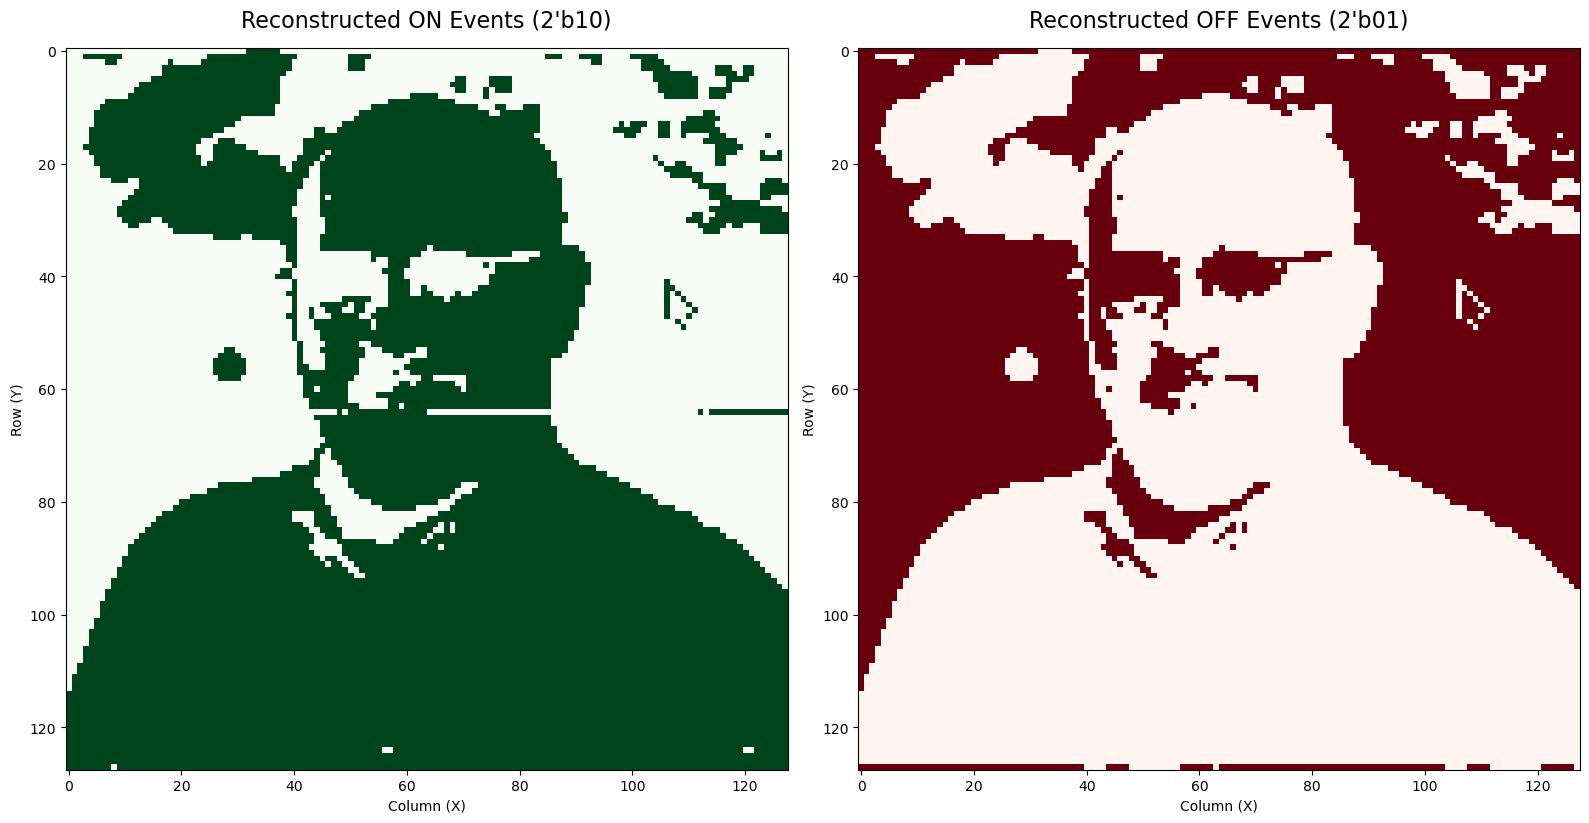

In [31]:
# 3. Visualize the Results
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot ON Events (Green/Hot)
cax1 = axes[0].imshow(on_events, cmap='Greens', interpolation='nearest')
axes[0].set_title('Reconstructed ON Events (2\'b10)', fontsize=16, pad=15)
axes[0].set_xlabel('Column (X)')
axes[0].set_ylabel('Row (Y)')
# fig.colorbar(cax1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot OFF Events (Red/Cool)
cax2 = axes[1].imshow(off_events, cmap='Reds', interpolation='nearest')
axes[1].set_title('Reconstructed OFF Events (2\'b01)', fontsize=16, pad=15)
axes[1].set_xlabel('Column (X)')
axes[1].set_ylabel('Row (Y)')
# fig.colorbar(cax2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()